In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL

## 1. Configuration

This notebook analyzes 2025 by default, but the whole thing is driven by the two dates in the
next cell rather than a hard-coded year. Change `START_DATE` / `END_DATE` and re-run top to
bottom to look at any other period (a single month, a heatwave week, all of 2022–2026, ...) —
every filter, trend plot and heatmap below reads from these two variables, nothing else
hard-codes a date.

In [2]:
# --- Configuration ------------------------------------------------------
# START_DATE is inclusive, END_DATE is exclusive (half-open interval), so the
# default below keeps every hour from 2025-01-01 00:00 through 2025-12-31 23:00.
START_DATE = "2025-01-01"
END_DATE = "2026-01-01"

DATA_PATH = "../data/smard_2022-2026.csv"

print(f"analysis window: {START_DATE} (inclusive) to {END_DATE} (exclusive)")

analysis window: 2025-01-01 (inclusive) to 2026-01-01 (exclusive)


## 2. Load and prepare

SMARD publishes its export in German Excel format: `;` as the column separator and `,` as the
decimal point. Pandas reads that fine as text, but every number column lands as a *string* until
we convert it — so the steps below are, in order: read the raw file, give the columns short
Python-friendly names, cut the data down to `START_DATE`–`END_DATE`, then convert the numeric
columns from `"12.345,67"`-style text to actual floats.

In [3]:
# Read the raw SMARD export. All columns other than the timestamp arrive as text
# (German decimal comma), which we fix a few cells down.
df = pd.read_csv(DATA_PATH, delimiter=';')

In [4]:
# Give the SMARD headers short, snake_case names. The remaining columns
# ("Wind Offshore", "Grid load", "Residual Load", "Solar") already become valid
# Python identifiers once lower-cased and space-replaced, so they don't need an
# explicit mapping here.
df.rename(
    columns={
        "Wind Offshore": "wind_off",
        "Wind Onshore": "wind_on",
        "Forecast Wind + Solar": "fc_gen_wind_solar",
        "Forecast Grid load": "fc_grid_load",
        "Forecast Residual Load": "fc_res"
    },
    inplace=True
)
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['timestamp', 'wind_off', 'wind_on', 'solar', 'grid_load',
       'residual_load', 'fc_gen_wind_solar', 'fc_grid_load', 'fc_res'],
      dtype='str')

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Keep only the configured window. Half-open ([start, end)) so END_DATE itself
# (midnight) is excluded and doesn't pull in one stray hour from the next period.
df = df[(df["timestamp"] >= START_DATE) & (df["timestamp"] < END_DATE)].copy()

# A short label for plot titles, so they stay accurate whatever window is
# configured above: "2025" if the data stays within one calendar year, or an
# explicit date range otherwise.
_start, _end_inclusive = df["timestamp"].min(), df["timestamp"].max()
if _start.year == _end_inclusive.year:
    PERIOD_LABEL = f"{_start.year}"
else:
    PERIOD_LABEL = f"{_start:%Y-%m-%d} to {_end_inclusive:%Y-%m-%d}"

print(f"{len(df):,} hourly rows kept, {_start} to {_end_inclusive}")
print(f"PERIOD_LABEL = {PERIOD_LABEL!r}")

8,759 hourly rows kept, 2025-01-01 00:00:00 to 2025-12-31 23:00:00
PERIOD_LABEL = '2025'


In [6]:
# Convert every numeric column from German-formatted text ("1.234,56") to float.
# Checking dtypes afterwards matters: if this step were skipped, pandas would
# silently keep the columns as strings and every later .mean()/.sum() would fail
# or (worse) quietly sort lexicographically instead of numerically.
numeric_cols = df.columns.tolist()
numeric_cols.remove("timestamp")

for col in numeric_cols:
    df[col] = df[col].str.replace(",", ".")
    df[col] = df[col].astype(float)

df.dtypes

timestamp            datetime64[us]
wind_off                    float64
wind_on                     float64
solar                       float64
grid_load                   float64
residual_load               float64
fc_gen_wind_solar           float64
fc_grid_load                float64
fc_res                      float64
dtype: object

### Calendar tags

Every row is one hour of electricity data, but "one hour" doesn't tell us *which kind* of hour
it is — a Tuesday rush-hour reading behaves very differently from a Sunday-at-3am reading, even
though both are just "an hour". The columns below are like sticky notes we attach to each row:
hour of day, day of week, week number, month, and season. Nothing about the data itself changes;
we're just labeling each row so we can later group and compare "all Monday mornings" or "all
winter afternoons" against each other.

In [7]:
# Create time features from the timestamp

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.dayofweek   # Monday = 0, Sunday = 6
df["day_name"] = df["timestamp"].dt.day_name()
df["week"] = df["timestamp"].dt.isocalendar().week.astype(int)
df["month"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.month_name()

In [8]:
# Assign meteorological seasons based on month.
# "Meteorological" (not astronomical) seasons split cleanly on calendar-month
# boundaries -- Dec/Jan/Feb, Mar/Apr/May, ... -- which is what lets us group by
# whole months later without a season crossing a month in the middle.

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

In [9]:
df.head(5)

,timestamp,wind_off,wind_on,solar,grid_load,residual_load,fc_gen_wind_solar,fc_grid_load,fc_res,hour,day,day_of_week,day_name,week,month,month_name,season
26301,2025-01-01 00:00:00,2502.00,32875.75,9.50,47741.75,12354.50,42231.75,44518.25,2286.50,0,1,2,Wednesday,1,1,January,Winter
26302,2025-01-01 01:00:00,2395.50,33520.00,9.50,46867.25,10942.25,42726.25,42269.25,-457.00,1,1,2,Wednesday,1,1,January,Winter
26303,2025-01-01 02:00:00,2614.00,33767.00,9.00,45797.50,9407.50,43215.00,41096.00,-2119.00,2,1,2,Wednesday,1,1,January,Winter
26304,2025-01-01 03:00:00,1684.25,32876.25,9.25,44623.50,10053.75,42684.50,40805.25,-1879.25,3,1,2,Wednesday,1,1,January,Winter
26305,2025-01-01 04:00:00,1327.75,33113.75,9.00,43626.00,9175.50,42895.25,40678.00,-2217.25,4,1,2,Wednesday,1,1,January,Winter


## 3. Daily trend

Averaging every column down to one number per calendar day smooths away the hour-to-hour
"rush hour" swings and leaves only the slower story: is Germany using more or less power this
week than last, and how does that drift over the year? Think of it like looking at a city's
traffic from a helicopter instead of standing at one intersection — you lose the individual
commute peaks, but you can finally see the citywide trend.

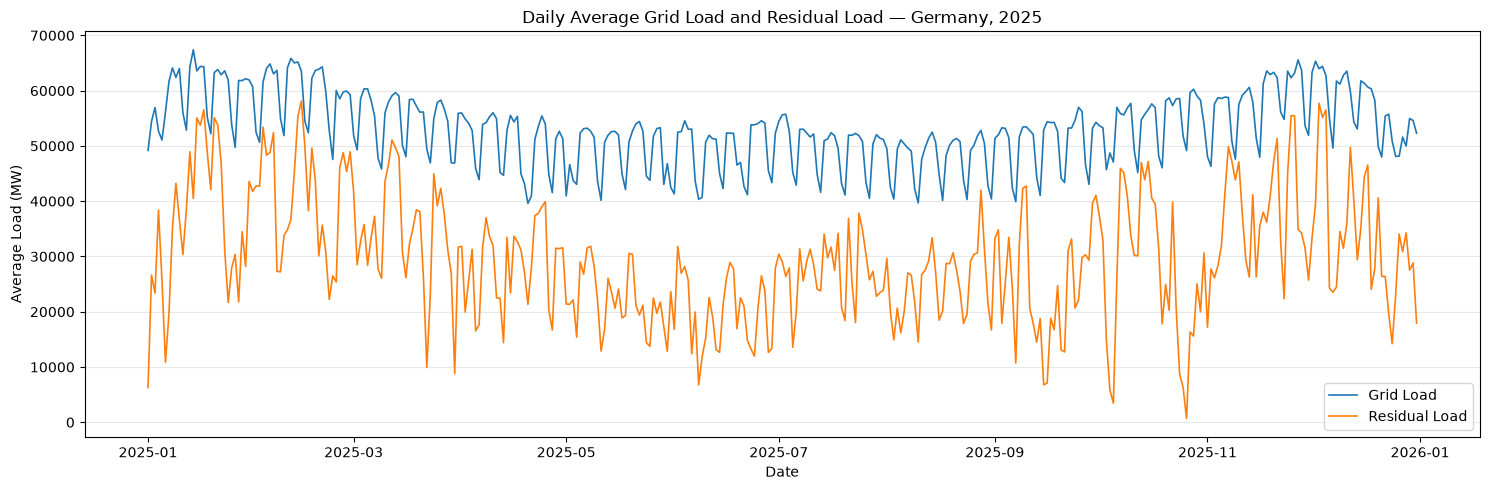

In [10]:
# Calculate average grid load and residual load for each day
daily = (
    df.set_index("timestamp")[["grid_load", "residual_load"]]
    .resample("D")
    .mean()
)

# Plot daily averages
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    daily.index,
    daily["grid_load"],
    label="Grid Load",
    linewidth=1.2
)

ax.plot(
    daily.index,
    daily["residual_load"],
    label="Residual Load",
    linewidth=1.2
)

ax.set_title(f"Daily Average Grid Load and Residual Load — Germany, {PERIOD_LABEL}")
ax.set_xlabel("Date")
ax.set_ylabel("Average Load (MW)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Weekly trend

Averaging by week zooms out one step further and mostly cancels out the weekday/weekend
difference (5 workdays + 2 quieter days, every single week), so what's left is closer to a
pure seasonal signal — like checking a thermostat's weekly average instead of its reading every
single time someone opens a door.

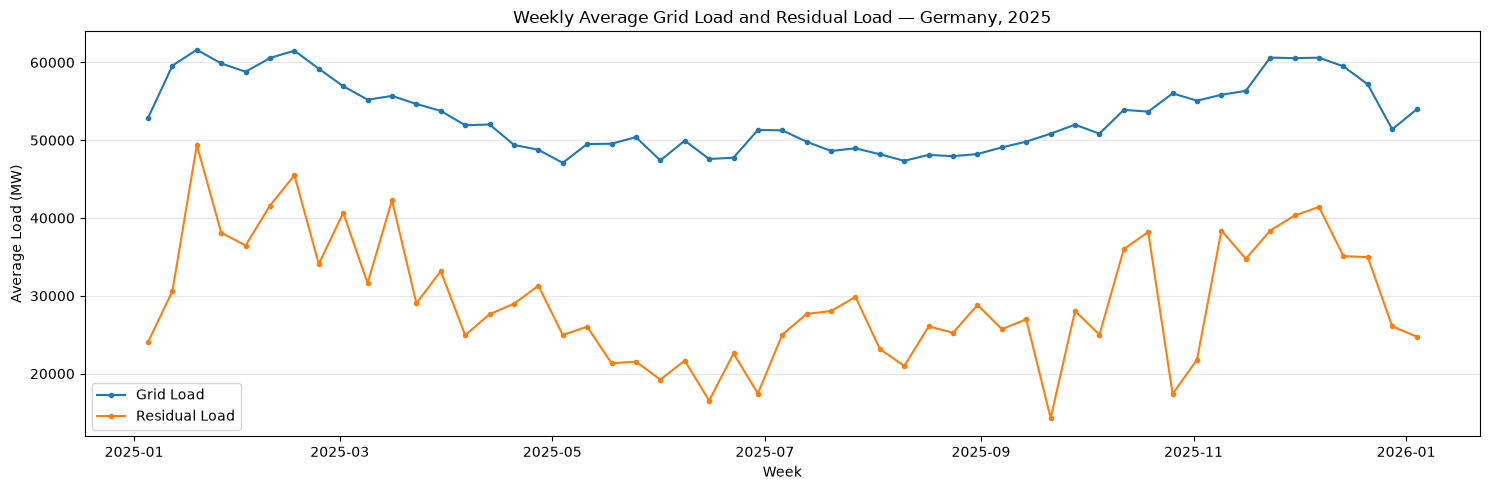

In [11]:
# Calculate weekly average grid load and residual load
weekly = (
    df.set_index("timestamp")[["grid_load", "residual_load"]]
    .resample("W")
    .mean()
)

# Plot weekly averages
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    weekly.index,
    weekly["grid_load"],
    label="Grid Load",
    marker="o",
    markersize=3
)

ax.plot(
    weekly.index,
    weekly["residual_load"],
    label="Residual Load",
    marker="o",
    markersize=3
)

ax.set_title(f"Weekly Average Grid Load and Residual Load — Germany, {PERIOD_LABEL}")
ax.set_xlabel("Week")
ax.set_ylabel("Average Load (MW)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Monthly trend

Monthly averages make the seasonal shape (winter-high, summer-low) obvious at a glance — this
is the resolution at which "Germany uses more electricity in January than in July" stops being
a statistic and starts looking like a simple, visible wave.

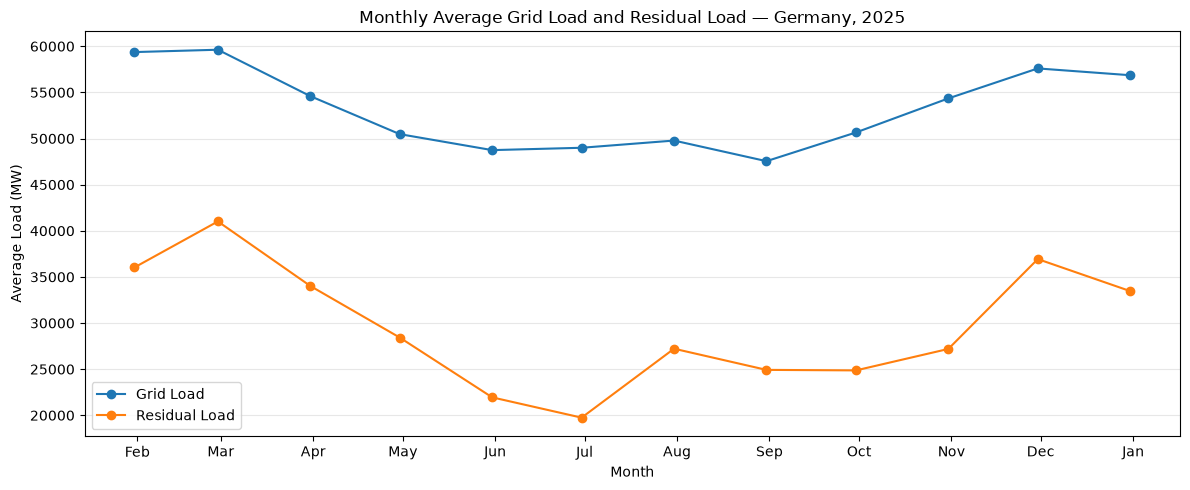

In [12]:
# Calculate monthly average grid load and residual load
monthly = (
    df.set_index("timestamp")[["grid_load", "residual_load"]]
    .resample("ME")
    .mean()
)

# Plot monthly averages
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly.index,
    monthly["grid_load"],
    marker="o",
    label="Grid Load"
)

ax.plot(
    monthly.index,
    monthly["residual_load"],
    marker="o",
    label="Residual Load"
)

ax.set_title(f"Monthly Average Grid Load and Residual Load — Germany, {PERIOD_LABEL}")
ax.set_xlabel("Month")
ax.set_ylabel("Average Load (MW)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Display abbreviated month names
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

## 6. Seasonal trend

Collapsing all the months into four seasonal buckets gives the clearest single-number summary
of the annual cycle: one bar each for winter, spring, summer, autumn. It trades away all the
day-to-day and week-to-week detail on purpose, the same way a "average temperature by season"
chart does for weather.

In [13]:
# Define the desired season order
season_order = ["Winter", "Spring", "Summer", "Autumn"]

# Calculate seasonal averages
seasonal = (
    df.groupby("season")[["grid_load", "residual_load"]]
    .mean()
    .reindex(season_order)
)

seasonal

,grid_load,residual_load
season,,
Winter,58584.484551,36694.161648
Spring,51277.776153,28124.740666
Summer,48771.538474,24008.186436
Autumn,54201.805696,29636.918810


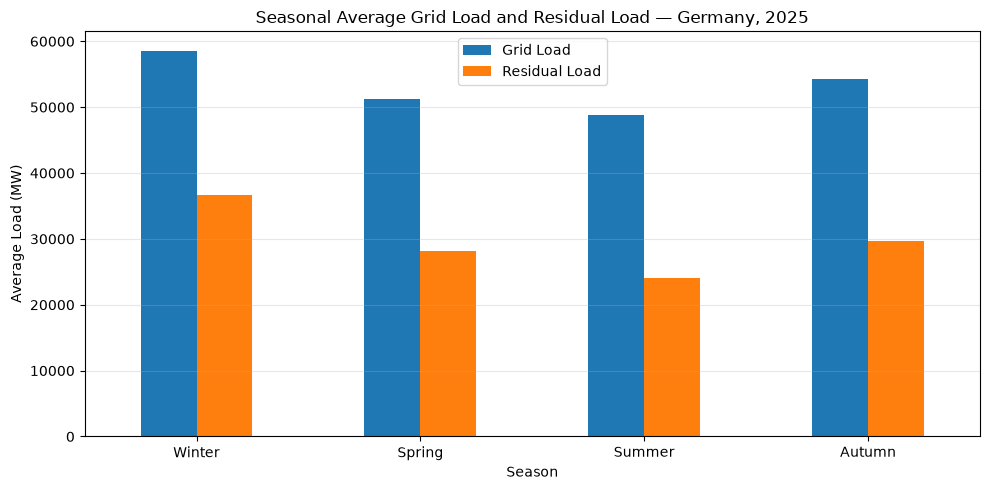

In [14]:
# Plot seasonal average load
ax = seasonal.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title(f"Seasonal Average Grid Load and Residual Load — Germany, {PERIOD_LABEL}")
ax.set_xlabel("Season")
ax.set_ylabel("Average Load (MW)")
ax.legend(["Grid Load", "Residual Load"])
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Weekly cycle heatmap — Grid Load

A heatmap here works like a gym's "busiest hours" chart: rows are the hour of day, columns are
the day of week, and color shows how much power is typically used in that exact hour/day
combination, averaged over the whole period. It packs the daily *and* weekly cycles into a
single picture — you can see the evening peak *and* the weekday/weekend contrast at once, which
neither the daily nor the weekly line chart above shows on its own.

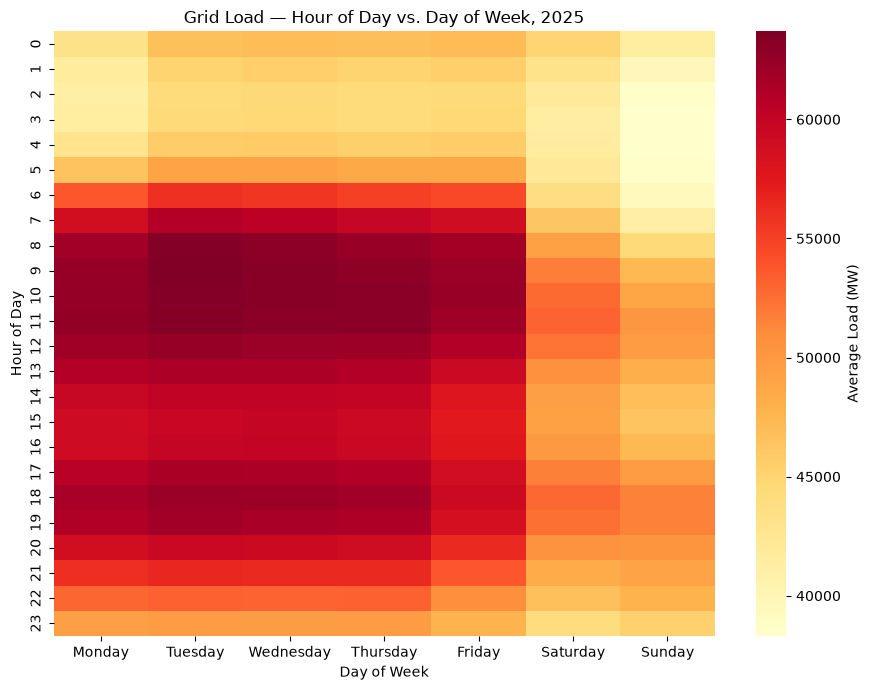

In [15]:
# Average grid load by hour of day and day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

grid_pivot = df.pivot_table(
    index="hour", columns="day_name", values="grid_load", aggfunc="mean"
)[day_order]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    grid_pivot,
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Average Load (MW)"}
)
ax.set_title(f"Grid Load — Hour of Day vs. Day of Week, {PERIOD_LABEL}")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")

plt.tight_layout()
plt.show()

## 8. Weekly cycle heatmap — Residual Load

Same idea, different question: instead of "how much power does Germany use", this asks "how
much of that power still needs to come from conventional plants after wind and solar have
already contributed". Because that number can go negative (renewables briefly producing *more*
than needed), the color scale below is centered on zero — blue shades mark hour/day
combinations where renewables typically cover demand on their own, red shades mark where the
gap is largest.

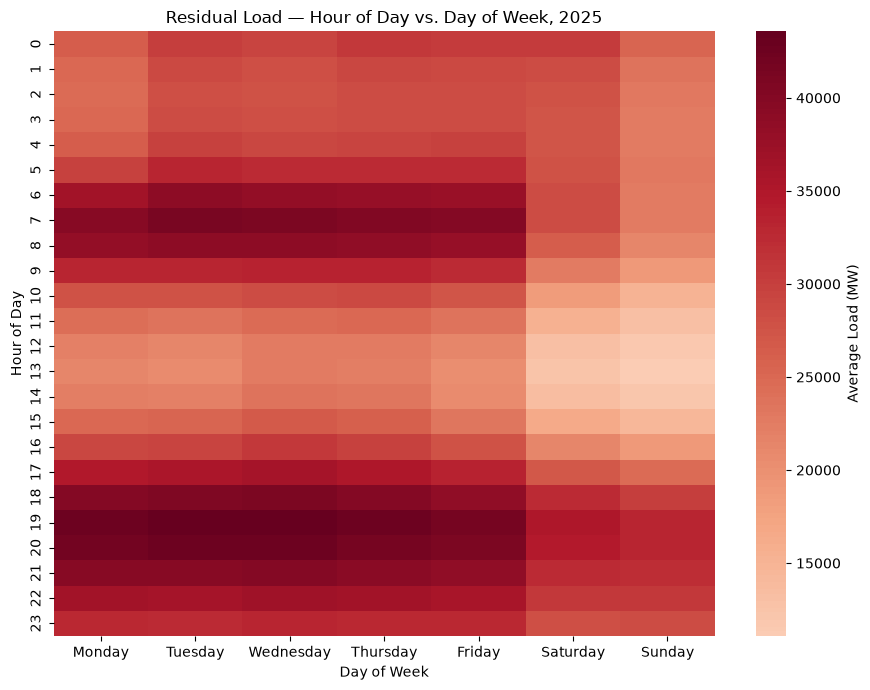

In [16]:
# Average residual load by hour of day and day of week
residual_pivot = df.pivot_table(
    index="hour", columns="day_name", values="residual_load", aggfunc="mean"
)[day_order]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    residual_pivot,
    cmap="RdBu_r",
    center=0,
    ax=ax,
    cbar_kws={"label": "Average Load (MW)"}
)
ax.set_title(f"Residual Load — Hour of Day vs. Day of Week, {PERIOD_LABEL}")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")

plt.tight_layout()
plt.show()

## 9. Load duration curve

Imagine sorting every hour of the year by how much load it had, from the single busiest hour
down to the quietest — like lining up a year's worth of daily grocery receipts from most to
least expensive, ignoring which day each one happened on. The x-axis below is no longer time;
it's "percentage of hours", so a point at (20%, 60,000 MW) means *"grid load was at or above
60,000 MW for 20% of the hours in this period"*. This view is the standard way grid operators
size how much *capacity* they need to have on hand, since it directly answers "how often do we
need this much power?" — a question the time-ordered charts above don't answer directly.

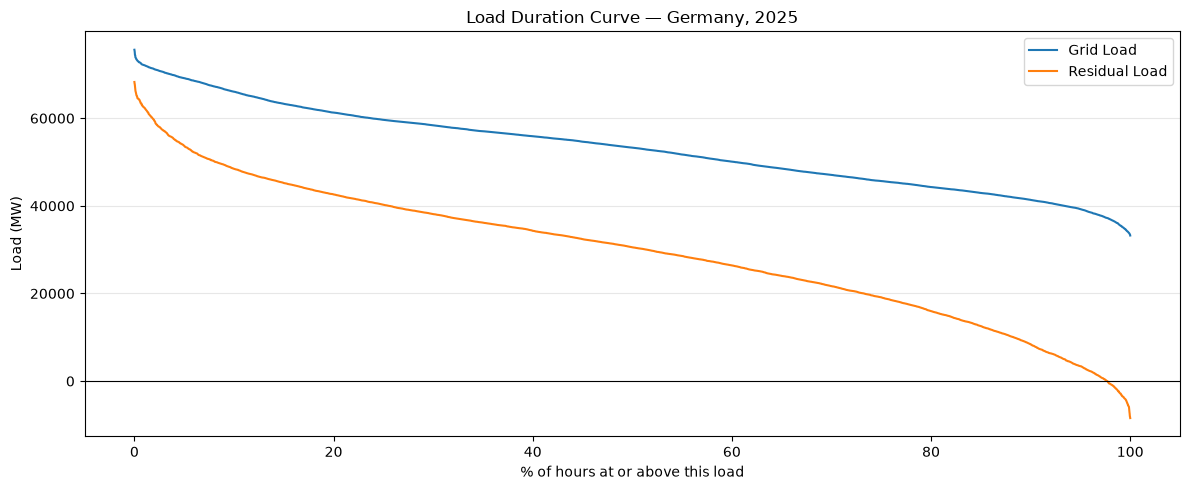

In [17]:
# Sort each series from largest to smallest, independent of when each value occurred,
# then express the x-axis as "% of hours" so the two series (and other periods/years)
# stay comparable regardless of how many hours are in the chosen window.
grid_sorted = df["grid_load"].sort_values(ascending=False).to_numpy()
residual_sorted = df["residual_load"].sort_values(ascending=False).to_numpy()
pct_of_hours = np.linspace(0, 100, len(df))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pct_of_hours, grid_sorted, label="Grid Load")
ax.plot(pct_of_hours, residual_sorted, label="Residual Load")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title(f"Load Duration Curve — Germany, {PERIOD_LABEL}")
ax.set_xlabel("% of hours at or above this load")
ax.set_ylabel("Load (MW)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Seasonal decomposition

Every chart so far has shown grid load as one tangled signal with several rhythms mixed
together. Decomposition is like separating a song's audio track back into its bassline,
melody, and background noise — it splits `grid_load` into:

- **Trend**: the slow-moving underlying level (is usage generally rising or falling?)
- **Seasonal**: the repeating daily up-and-down pattern (the "rush hour" shape, repeated every
  24 hours)
- **Residual**: whatever is left over once trend and seasonality are removed — the part driven
  by weather, holidays, and other one-off effects

We use `STL` (Seasonal-Trend decomposition using LOESS) with a 24-hour period, since the
dominant repeating cycle in hourly load data is the daily one.

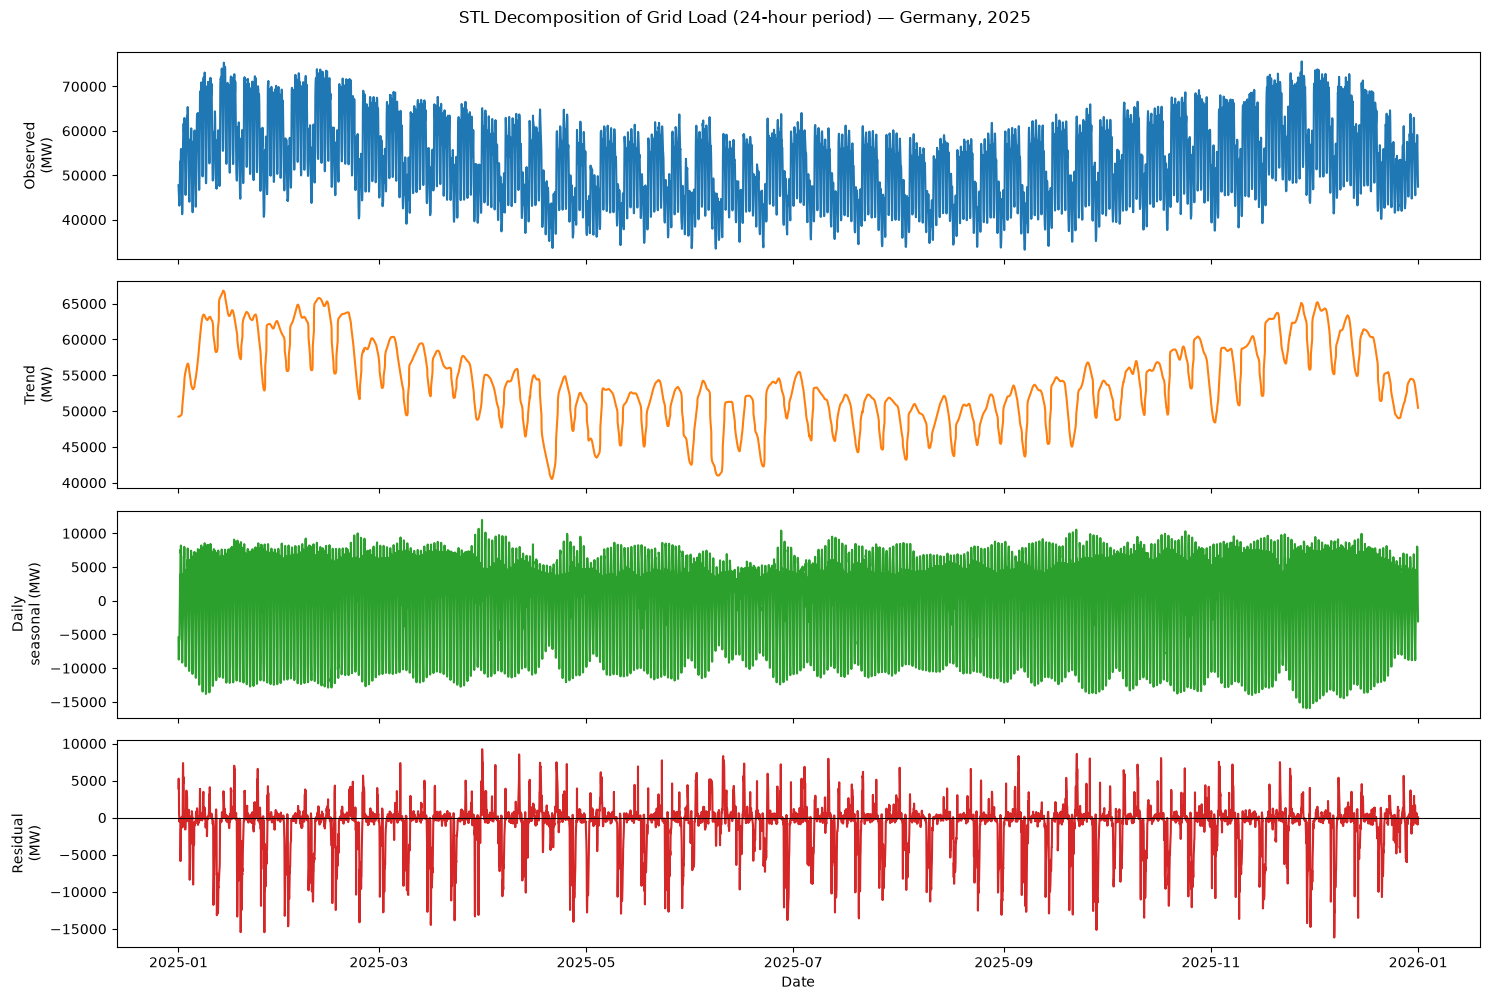

In [18]:
# STL needs a plain time-indexed series. `period=24` tells it the repeating
# cycle is one day long (24 hourly observations).
grid_series = df.set_index("timestamp")["grid_load"]

stl_result = STL(grid_series, period=24, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

axes[0].plot(grid_series.index, grid_series, color="C0")
axes[0].set_ylabel("Observed\n(MW)")

axes[1].plot(grid_series.index, stl_result.trend, color="C1")
axes[1].set_ylabel("Trend\n(MW)")

axes[2].plot(grid_series.index, stl_result.seasonal, color="C2")
axes[2].set_ylabel("Daily\nseasonal (MW)")

axes[3].plot(grid_series.index, stl_result.resid, color="C3")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("Residual\n(MW)")
axes[3].set_xlabel("Date")

fig.suptitle(f"STL Decomposition of Grid Load (24-hour period) — Germany, {PERIOD_LABEL}", y=0.995)
plt.tight_layout()
plt.show()

## 11. Understanding lags

A **lag** is just "the same series, shifted back in time" — lag-1 is last hour's value, lag-24
is the same hour yesterday, lag-168 is the same hour one week ago. Lags matter because most
forecasting starts from the same intuition a person would use: *tomorrow at 6pm probably looks
like today at 6pm, and even more like last Tuesday at 6pm if today isn't a Tuesday*. Lags turn
that intuition into features a model can actually use, and the daily/weekly rhythms already
visible in the heatmaps above are exactly what shows up as lag structure below.

**How to find which lags matter:** the **ACF** (autocorrelation function) plots the correlation
between a series and itself at every lag, so a spike at lag 24 says "24 hours ago is a strong
predictor of now." The **PACF** (partial autocorrelation) strips out what's already explained by
shorter lags in between, isolating each lag's *independent* contribution — this is what tells us
whether lag 48 adds anything beyond what lags 1–24 already captured, rather than just echoing
them.

**Pitfalls to watch for:**
- **Redundant lags.** Nearby lags are highly correlated with each other, not just with the
  target — including both lag 23 and lag 24 rarely helps and can destabilize a model.
- **Calendar gaps.** Because of the DST switches noted earlier, consecutive rows aren't always
  exactly one hour apart, so "lag 24" isn't always exactly 24 hours in real time.
- **Trend/seasonality inflate the ACF.** A strongly seasonal series shows high correlation at
  almost every lag near a multiple of its cycle, which can look like "everything matters" when
  really one or two lags plus a seasonal term would do.

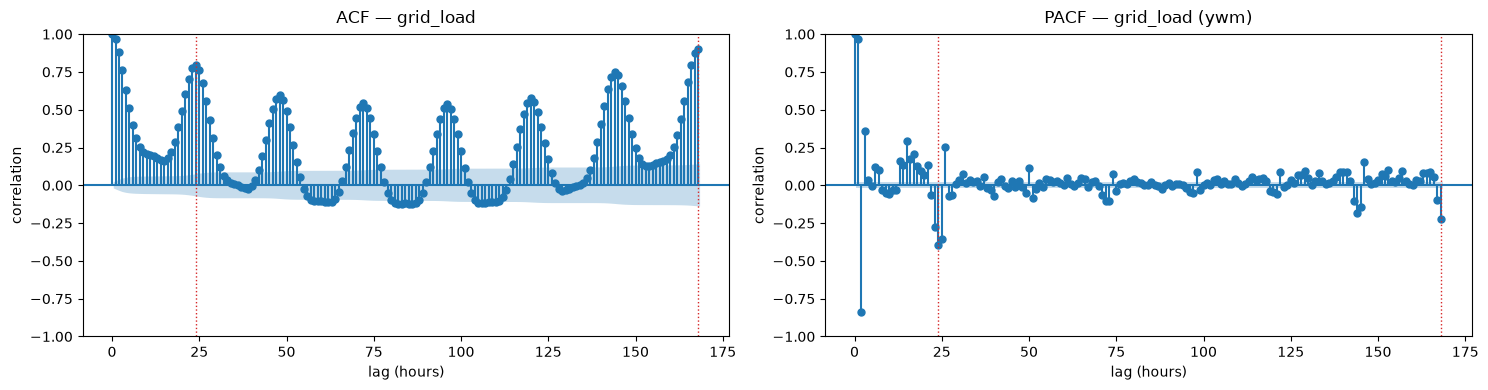

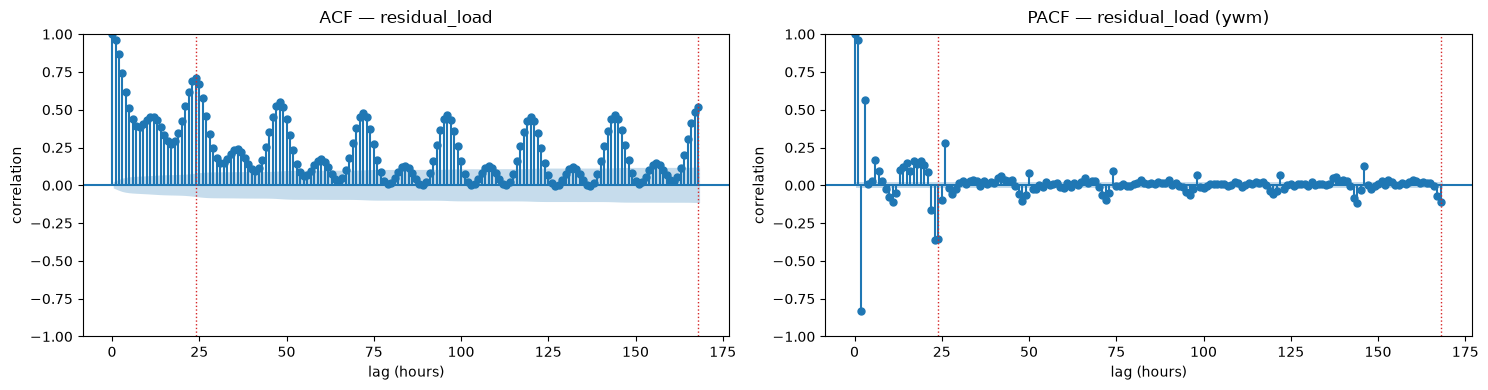

,grid_load,residual_load
lag 1 h,0.967131,0.963943
lag 24 h,0.797415,0.711912
lag 48 h,0.596457,0.555313
lag 168 h,0.912828,0.523197


In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF/PACF out to 168 hours (one week) for grid_load and residual_load, with
# dotted reference lines at the 24h (daily) and 168h (weekly) marks so the
# calendar rhythms are easy to spot directly in the correlation plots.
for col in ["grid_load", "residual_load"]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    series = df[col].to_numpy()

    plot_acf(series, lags=168, ax=axes[0])
    plot_pacf(series, lags=168, method="ywm", ax=axes[1])

    for ax, title in zip(axes, [f"ACF — {col}", f"PACF — {col} (ywm)"]):
        ax.set_title(title, fontsize=12, pad=8)
        ax.set_xlabel("lag (hours)")
        ax.set_ylabel("correlation")
        for lag in (24, 168):
            ax.axvline(lag, color="C3", linestyle=":", linewidth=1)

    plt.tight_layout()
    plt.show()

# A compact numeric summary of the same idea: how strongly correlated is each
# series with itself at a few calendar-motivated lags?
LAGS = [1, 24, 48, 168]
lag_corr = pd.DataFrame(
    {
        col: {f"lag {lag} h": df[col].corr(df[col].shift(lag)) for lag in LAGS}
        for col in ["grid_load", "residual_load"]
    }
)
lag_corr

## 12. What these patterns mean, in plain language

Think of Germany's power grid like a giant bathtub that must always stay at the same water
level. "Grid load" is water constantly draining out — that's everyone switching on lights,
running factories, and charging devices. "Residual load" is how much water someone has to pour
back in by hand, after the rain (wind and solar) has already added what it could on its own.

The charts above show three familiar rhythms in this bathtub, all repeating like clockwork:

- **A daily rhythm**: demand rises as people wake up and go to work, peaks in the
  daytime and early evening, then falls overnight while most of the country sleeps — this
  shows up as the light-to-dark banding in the heatmaps, hour by hour, as the "daily
  seasonal" panel in the decomposition, and as the 24h spike in the ACF/PACF plots.
- **A weekly rhythm**: weekdays pull noticeably more power than weekends, because
  factories and offices are closed on Saturday and Sunday — visible as the heatmap columns
  turning cooler toward the right, and as the 168h echo in the lag correlations.
- **A seasonal rhythm**: winter months need the most power overall (heating, less
  daylight), while spring and summer need less — but summer also gets more free "rain" from
  solar panels, so less needs to be poured in by hand and residual load drops even faster than
  grid load does.

The load duration curve answers a different, very practical question: not "when" does Germany
use a lot of power, but "how often". A grid operator reading it can say "we only need our very
largest power plants running for the top 5% of hours" — the rest of the time, less capacity
is needed.

The gap between the two lines — grid load and residual load — is essentially the story of
wind and solar doing their job. When that gap narrows, renewables are covering most of demand;
when it widens (cold, dark, still days), conventional power plants have to step in to keep the
"bathtub" full. Spotting exactly when that gap gets unusually wide or unusually narrow is what
the rest of this project is about: flagging the days when keeping the grid balanced is hardest.